# Fused Pipeline v4: Semi-Supervised ResNet-50 + Wavelet Hybrid — Breast Cancer Classification

**v1 -> v2 -> v3 -> v4**, based on running each version and comparing actual results:

- **v1** scored *worse* (70.6% macro F1 test) than the plain (non-semi-supervised) ResNet50+Wavelet
  hybrid (72.2%), with training F1 hitting 99.9% while validation F1 sat around 70% -- classic
  overfitting.
- **v2** fixed that overfitting (train F1 89% vs val F1 70%) but the *final* test score barely moved
  (69.4%), because self-training was quietly re-skewing the dataset toward "Normal" (78% of all
  accepted pseudo-labels across 5 iterations, vs 3.5% for Malignant).
- **v3** fixed that specific bug with per-class pseudo-label thresholds + a hard cap -- verified
  working (every iteration accepted exactly 200/200/200 per class, hitting the cap rather than the
  threshold). But test macro F1 still didn't move (69.95%) -- the self-training imbalance was a real
  bug, but it was never the actual bottleneck. The per-class classification report showed why: Benign
  (F1 0.57) is dragging the average down hard, while Malignant (0.74) and Normal (0.79) are both
  reasonably solid. Train/val F1 gap also persisted (84.99% vs 70.64%).
- **v4** (this version) targets the Benign weakness and the residual overfitting directly, and fixes
  a real bug found while reviewing v3's code.

## What's new in v4

1. **Bug fix: `CLASS_WEIGHT_MODE` was dead code.** v3 computed a `class_weight` dict in a cell right
   after building the generators, but **no `model.fit()` call anywhere in the notebook actually used
   it** -- not Phase 1, not the self-training loop, not Phase 3. The toggle existed and printed output,
   but had zero effect on training. This is fixed below.
2. **`CLASS_WEIGHT_MODE = 'balanced'` would have been a no-op anyway -- don't use it.** `labeled_train`
   is already near-perfectly frequency-balanced (Benign 1714 / Malignant 1714 / Normal 1715), so
   sklearn's inverse-frequency `'balanced'` weighting would come out to ~1.0 for every class -- doing
   nothing. Benign's weakness isn't a *frequency* problem (v3 already fixed frequency, twice over,
   between the upstream balancing and the per-class pseudo-label cap) -- it's a *separability* problem:
   the model finds Benign genuinely harder to tell apart from its neighbors in feature space. A
   frequency-based weight can't fix that.
3. **NEW: `CLASS_WEIGHT_MODE = 'recall_inverse'`** -- instead of guessing which class needs help (v1's
   hardcoded Malignant boost turned out to target the wrong class once Benign became the weak link),
   this **measures** each class's recall on `val_generator` using the self-trained model, right before
   Phase 3, and weights inversely to that: whichever class the model is currently worst at gets the
   biggest boost, automatically. If a future run's weak class shifts again, this adapts without you
   having to notice and hand-edit a constant. Applied only in Phase 3 (fine-tuning), per the plan v3's
   own closing notes already sketched out.
4. **Confusion matrix is now also printed as raw numbers**, not just plotted -- specifically calling out
   what fraction of Benign's errors go to Malignant vs. Normal, since that determines whether this is a
   genuine clinical-lookalike problem (errors go to Malignant) or something else (errors go to Normal).
5. **Optional mild additive Gaussian noise augmentation** (off by default via `USE_GAUSSIAN_NOISE`), as
   v3's own closing notes suggested as the safe next augmentation step: unlike rotation/zoom, noise
   isn't a resampling operation, so it doesn't compound blur on the ~10% of images that are already
   synthetic balancing copies mixed into `labeled_train`/`unlabeled_train`.
6. **`FINETUNE_UNFREEZE_LAST_N` lowered from 15 to 10** -- the train/val gap (84.99% vs 70.64%) is
   smaller than v1's blowout but still real; unfreezing less of the backbone is the cheapest lever left
   before touching augmentation or architecture further.

Everything else (per-class threshold + cap self-training, flip-only augmentation, dual-branch
ResNet50+wavelet architecture, three-phase structure) is unchanged from v3 because it's already
verified working.

### Pipeline phases (unchanged)
- **Phase 1** — train the frozen-backbone hybrid model on `labeled_train` only (augmented).
- **Phase 2** — iterative self-training with per-class threshold + cap, early stopping, per-class logging.
- **Phase 3** — lighter fine-tuning of the ResNet-50 backbone, now with measured class weighting.
- **Phase 4** — evaluate on train/val/test; classification report; confusion matrix (plot + raw numbers).

### Expected data layout (unchanged)
```
Semi_Supervised_Balanced/
    labeled_train/<class>/*.jpg
    unlabeled_train/<class or single dummy folder>/*.jpg
    val/<class>/*.jpg
    test/<class>/*.jpg
```


In [1]:
# ==========================================================
# GPU CHECK
# ==========================================================
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print("TensorFlow Version: ", tf.__version__)


Num GPUs Available:  1
TensorFlow Version:  2.10.0


In [2]:
# ==========================================================
# IMPORTS
# ==========================================================
print("start")

import os
import shutil
import random
import numpy as np
import cv2
import pywt
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, GlobalAveragePooling2D, Dropout, Concatenate, BatchNormalization
)
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import Sequence
from tensorflow.keras.metrics import Precision, Recall
import tensorflow_addons as tfa
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
    Callback
)

print("done1")


start
done1


In [3]:
# ==========================================================
# SEMI-SUPERVISED DATASET DIRECTORY (BALANCED)
# ==========================================================
# Same directory the semi-supervised EfficientNetB3 notebook uses --
# labeled_train / unlabeled_train / val / test, built by the preprocessing
# pipeline (P3_fixed_final_Pipeline_v11). labeled_train/unlabeled_train/val
# come from the augmented, balanced pool; test is the raw, untouched,
# held-out set shared across all your models so results stay comparable.
print("start")

base_path = r"D:\Thesis_folder\Preprocessed_Pipeline\Semi_Supervised_Balanced"

labeled_dir = os.path.join(base_path, "labeled_train")
unlabeled_dir = os.path.join(base_path, "unlabeled_train")
val_dir = os.path.join(base_path, "val")
test_dir = os.path.join(base_path, "test")
train_combined_dir = os.path.join(base_path, "train_combined")

for split_dir in [labeled_dir, unlabeled_dir, val_dir, test_dir]:
    if not os.path.isdir(split_dir):
        raise FileNotFoundError(
            f"'{split_dir}' not found. Run the preprocessing pipeline "
            "(P3_fixed_final_Pipeline_v11) through the semi-supervised split step first."
        )
    classes_found = [d for d in os.listdir(split_dir) if os.path.isdir(os.path.join(split_dir, d))]
    counts = {cls: len(os.listdir(os.path.join(split_dir, cls))) for cls in classes_found}
    print(f"{os.path.basename(split_dir)}: {counts}")

print("done1")


start
labeled_train: {'Benign': 1714, 'Malignant': 1714, 'Normal': 1715}
unlabeled_train: {'Benign': 4286, 'Malignant': 4286, 'Normal': 4285}
val: {'Benign': 931, 'Malignant': 1239, 'Normal': 795}
test: {'Benign': 888, 'Malignant': 1266, 'Normal': 789}
done1


In [4]:
# ==========================================================
# CONFIGURATION & PARAMETERS  (v4)
# ==========================================================
print("start")

IMAGE_SIZE = (288, 288)
MODEL_INPUT_SIZE = (288, 288, 3)
NUM_CLASSES = 3
BATCH_SIZE = 32
EPOCHS_PHASE1 = 150

WAVELET_NAME = "db1"
WAVELET_LEVEL = 2

# --- Semi-supervised self-training schedule (unchanged from v3 -- verified working) ---
NUM_ITERATIONS = 5
EPOCHS_PER_ITERATION = 7
CONFIDENCE_THRESHOLD = 0.90   # fallback threshold for any class not in PER_CLASS_THRESHOLD

PER_CLASS_THRESHOLD = {
    "Normal": 0.93,
    "Benign": 0.85,
    "Malignant": 0.85,
}
MAX_ACCEPT_PER_CLASS_PER_ITER = 200

SELFTRAIN_EARLYSTOP_PATIENCE = 3

# --- Fine-tuning schedule ---
EPOCHS_FINETUNE = 25
FINETUNE_UNFREEZE_LAST_N = 10     # v4: was 15 -- train/val F1 gap (85% vs 71%) is still real;
                                    # unfreezing less of the backbone is the cheapest next lever.

# --- Regularization (unchanged from v3) ---
DROPOUT_RATE = 0.4
L2_REG = 1e-4

# --- Data augmentation ---
AUGMENT_TRAIN = True    # flip only, unchanged from v3 -- see the Gaussian noise note below for why
                         # rotation/zoom/jitter are still avoided here.
USE_GAUSSIAN_NOISE = False   # v4 NEW, OFF by default: mild additive Gaussian noise, applied on top
                              # of the flip. Unlike rotation/zoom, noise is not a resampling operation,
                              # so it does not compound interpolation blur on the ~10% of images that
                              # are already synthetic balancing copies. Try turning this on if v4's
                              # train/val gap is still large after the FINETUNE_UNFREEZE_LAST_N change.
GAUSSIAN_NOISE_STD = 4.0     # in 0-255 pixel units; small and easy to raise/lower

# --- Class weighting (v4: rewritten) ---
# v3 computed a class_weight dict here but NEVER PASSED IT to any model.fit() call anywhere in the
# notebook -- Phase 1, the self-training loop, and Phase 3 all ignored it. That's fixed in v4: the
# weight is now actually applied, but only in Phase 3, and only using a mode that can actually help.
#
#   None            -- disabled (default before this run; matches v1/v2/v3's actual behavior)
#   'balanced'      -- sklearn inverse-frequency weighting. NOTE: labeled_train is already
#                       near-perfectly frequency-balanced (1714/1714/1715), so this mode will compute
#                       weights close to 1.0 for every class -- i.e. close to a no-op. Kept only for
#                       completeness / if you re-run on a differently-balanced split later.
#   'recall_inverse' -- v4 NEW. Measures each class's recall on val_generator using the self-trained
#                       model (right before Phase 3), then weights inversely to that -- whichever class
#                       the model is CURRENTLY worst at (Benign, in the last run) gets the biggest
#                       boost, automatically, instead of hand-picking a class in advance.
CLASS_WEIGHT_MODE = "recall_inverse"
CLASS_WEIGHT_MAX_MULTIPLIER = 3.0   # caps how large any single class's weight can get, so one very
                                     # low recall value can't destabilize the loss

print("done1")


start
done1


In [5]:
# ==========================================================
# WAVELET FEATURE EXTRACTION (unchanged from v3)
# ==========================================================
# 2D Discrete Wavelet Transform on the grayscale image; every sub-band
# (approximation + horizontal/vertical/diagonal detail, at every decomposition
# level) is summarised with mean, std and normalised energy. This gives a
# compact, complementary texture descriptor that is concatenated with the
# ResNet-50 deep features.
print("start")

def extract_wavelet_features(image_rgb, wavelet=WAVELET_NAME, level=WAVELET_LEVEL):
    """
    image_rgb: HxWx3 uint8 or float array (0-255 range)
    Returns: 1D float32 feature vector
    """
    gray = cv2.cvtColor(image_rgb.astype(np.uint8), cv2.COLOR_RGB2GRAY)
    coeffs = pywt.wavedec2(gray, wavelet=wavelet, level=level)

    features = []
    for idx, c in enumerate(coeffs):
        if idx == 0:
            sub_bands = [c]                 # approximation coefficients
        else:
            sub_bands = list(c)             # (cH, cV, cD) detail coefficients

        for sub in sub_bands:
            features.append(sub.mean())
            features.append(sub.std())
            features.append(np.sum(sub.astype(np.float64) ** 2) / sub.size)

    return np.array(features, dtype=np.float32)


def get_wavelet_feature_dim():
    dummy = np.zeros((IMAGE_SIZE[0], IMAGE_SIZE[1], 3), dtype=np.uint8)
    return extract_wavelet_features(dummy).shape[0]


WAVELET_FEATURE_DIM = get_wavelet_feature_dim()
print(f"Wavelet feature vector length: {WAVELET_FEATURE_DIM}")
print("done1")


start
Wavelet feature vector length: 21
done1


In [6]:
# ==========================================================
# AUGMENTATION (v4: flip, plus optional Gaussian noise)
# ==========================================================
# IMPORTANT: the upstream preprocessing pipeline already balances classes by inserting synthetic
# augmented copies (~10% of images) directly into labeled_train / unlabeled_train, with no way to
# tell those apart from genuine originals at this stage. Rotation/zoom/jitter are resampling
# operations -- applying them AGAIN on top of an already-augmented image compounds interpolation
# blur. Flip and additive noise are NOT resampling operations, so neither compounds that blur even
# when applied to an already-augmented image.
print("start")

def augment_image(img_rgb):
    if random.random() < 0.5:
        img_rgb = np.ascontiguousarray(np.fliplr(img_rgb))
    if USE_GAUSSIAN_NOISE:
        noise = np.random.normal(0.0, GAUSSIAN_NOISE_STD, img_rgb.shape).astype(np.float32)
        img_rgb = np.clip(img_rgb.astype(np.float32) + noise, 0, 255).astype(np.uint8)
    return img_rgb

print("done1")


start
done1


In [7]:
# ==========================================================
# DUAL-INPUT DATA GENERATOR (ResNet-50 image branch + wavelet branch)  (unchanged from v3)
# ==========================================================
class ResNetWaveletGenerator(Sequence):
    def __init__(self, directory, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
                 num_classes=NUM_CLASSES, shuffle=True, labeled=True,
                 class_indices=None, exclude_filepaths=None, augment=False):
        self.directory = directory
        self.image_size = image_size
        self.batch_size = batch_size
        self.num_classes = num_classes
        self.shuffle = shuffle
        self.labeled = labeled
        self.augment = augment

        self.class_names = sorted(
            d for d in os.listdir(directory)
            if os.path.isdir(os.path.join(directory, d))
        )
        self.class_indices = class_indices or {name: i for i, name in enumerate(self.class_names)}

        exclude_filepaths = exclude_filepaths or set()

        self.filepaths = []
        self.labels = []
        for cls in self.class_names:
            cls_dir = os.path.join(directory, cls)
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")):
                    fpath = os.path.join(cls_dir, fname)
                    if fpath in exclude_filepaths:
                        continue
                    self.filepaths.append(fpath)
                    self.labels.append(self.class_indices.get(cls, 0))

        self.labels = np.array(self.labels)
        self.indices = np.arange(len(self.filepaths))
        self.on_epoch_end()

    def __len__(self):
        return max(1, int(np.ceil(len(self.filepaths) / self.batch_size)))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]

        batch_images = np.zeros((len(batch_idx), *self.image_size, 3), dtype=np.float32)
        batch_wavelets = np.zeros((len(batch_idx), WAVELET_FEATURE_DIM), dtype=np.float32)
        batch_labels = np.zeros((len(batch_idx), self.num_classes), dtype=np.float32)

        for i, fi in enumerate(batch_idx):
            img_bgr = cv2.imread(self.filepaths[fi])
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            img_rgb = cv2.resize(img_rgb, self.image_size)

            if self.augment:
                img_rgb = augment_image(img_rgb)

            batch_wavelets[i] = extract_wavelet_features(img_rgb)
            batch_images[i] = preprocess_input(img_rgb.astype(np.float32))

            if self.labeled:
                batch_labels[i, self.labels[fi]] = 1.0

        if self.labeled:
            return [batch_images, batch_wavelets], batch_labels
        return [batch_images, batch_wavelets], None

    def filepaths_for_batch(self, idx):
        batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        return [self.filepaths[i] for i in batch_idx]

print("ResNetWaveletGenerator ready")


ResNetWaveletGenerator ready


In [8]:
# ==========================================================
# BUILD LABELED / VAL / TEST GENERATORS
# ==========================================================
print("start")

train_labeled_generator = ResNetWaveletGenerator(
    labeled_dir, shuffle=True, labeled=True, augment=AUGMENT_TRAIN
)

val_generator = ResNetWaveletGenerator(
    val_dir, shuffle=False, labeled=True, augment=False,
    class_indices=train_labeled_generator.class_indices
)

test_generator = ResNetWaveletGenerator(
    test_dir, shuffle=False, labeled=True, augment=False,
    class_indices=train_labeled_generator.class_indices
)

class_names = train_labeled_generator.class_names
print("Class indices:", train_labeled_generator.class_indices)

assert len(class_names) == NUM_CLASSES, (
    f"Expected {NUM_CLASSES} classes, found {len(class_names)}. "
    "Rerun the preprocessing pipeline from a clean state."
)
assert set(val_generator.filepaths).isdisjoint(set(test_generator.filepaths)), (
    "val_generator and test_generator appear to overlap."
)

print("done1")


start
Class indices: {'Benign': 0, 'Malignant': 1, 'Normal': 2}
done1


In [9]:
# ==========================================================
# MODEL DEFINITION: ResNet-50 (image branch) + Wavelet MLP (feature branch)  (unchanged from v3)
# ==========================================================
print("start")

f1_metric = tfa.metrics.F1Score(num_classes=NUM_CLASSES, average='macro', name='f1_score')
precision_metric = Precision(name='precision')
recall_metric = Recall(name='recall')

def get_ResNet50_Wavelet_Hybrid(learning_rate=1e-4):
    image_input = Input(shape=MODEL_INPUT_SIZE, name="image_input")
    base_model = ResNet50(
        input_tensor=image_input,
        weights='imagenet',
        include_top=False
    )
    base_model.trainable = False

    x_img = GlobalAveragePooling2D()(base_model.output)
    x_img = Dropout(DROPOUT_RATE)(x_img)

    wavelet_input = Input(shape=(WAVELET_FEATURE_DIM,), name="wavelet_input")
    x_wav = BatchNormalization()(wavelet_input)
    x_wav = Dense(64, activation='relu', kernel_regularizer=regularizers.l2(L2_REG))(x_wav)
    x_wav = Dropout(DROPOUT_RATE)(x_wav)

    fused = Concatenate()([x_img, x_wav])
    fused = Dense(128, activation='relu', kernel_regularizer=regularizers.l2(L2_REG))(fused)
    fused = Dropout(DROPOUT_RATE)(fused)
    output = Dense(NUM_CLASSES, activation='softmax', kernel_regularizer=regularizers.l2(L2_REG))(fused)

    model = Model(inputs=[image_input, wavelet_input], outputs=output)

    optimizer = Adam(learning_rate=learning_rate)
    model.compile(
        loss="categorical_crossentropy",
        metrics=["accuracy", f1_metric, precision_metric, recall_metric],
        optimizer=optimizer
    )

    return model, base_model

model, base_model = get_ResNet50_Wavelet_Hybrid()
model.summary()

print("done1")


start
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 image_input (InputLayer)       [(None, 288, 288, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 294, 294, 3)  0           ['image_input[0][0]']            
                                                                                                  
 conv1_conv (Conv2D)            (None, 144, 144, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                        

In [10]:
# ==========================================================
# CALLBACKS -- PHASE 1 (frozen backbone, labeled-only training)
# ==========================================================
print("start")

early_stop = EarlyStopping(
    monitor='val_f1_score', mode='max', patience=11, restore_best_weights=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_f1_score', mode='max', factor=0.3, patience=5, min_lr=1e-7, verbose=1
)
checkpoint_initial = ModelCheckpoint(
    "ResNet50_Wavelet_SemiSupervised_Initial_v4.h5",
    monitor='val_f1_score', save_best_only=True, save_weights_only=True, mode='max', verbose=1
)

class PrintLearningRate(Callback):
    def on_epoch_end(self, epoch, logs=None):
        lr = self.model.optimizer.learning_rate.numpy()
        print(f"\nEpoch {epoch+1} Learning Rate : {lr}")

lr_callback = PrintLearningRate()

print("done1")


start
done1


In [11]:
# ==========================================================
# PHASE 1: INITIAL MODEL TRAINING (labeled subset only, frozen backbone, augmented)
# ==========================================================
# No class weighting here -- Phase 1's job is just to produce a reasonable starting classifier for
# self-training to build on; the measured, targeted weighting is applied later, in Phase 3, once we
# know (from val_generator) which class is actually still struggling after self-training.
print("start")

history_initial = model.fit(
    train_labeled_generator,
    validation_data=val_generator,
    epochs=EPOCHS_PHASE1,
    callbacks=[early_stop, reduce_lr, checkpoint_initial, lr_callback]
)

print("Initial baseline model training complete")


start
Epoch 1/150
161/161 [==============================] - ETA: 0s - loss: 1.2150 - accuracy: 0.4657 - f1_score: 0.4650 - precision: 0.4853 - recall: 0.3696
Epoch 1: val_f1_score improved from -inf to 0.58134, saving model to ResNet50_Wavelet_SemiSupervised_Initial_v4.h5

Epoch 1 Learning Rate : 9.999999747378752e-05
161/161 [==============================] - 125s 758ms/step - loss: 1.2150 - accuracy: 0.4657 - f1_score: 0.4650 - precision: 0.4853 - recall: 0.3696 - val_loss: 0.9330 - val_accuracy: 0.5788 - val_f1_score: 0.5813 - val_precision: 0.6911 - val_recall: 0.2927 - lr: 1.0000e-04
Epoch 2/150
161/161 [==============================] - ETA: 0s - loss: 0.9827 - accuracy: 0.5349 - f1_score: 0.5319 - precision: 0.5884 - recall: 0.4066
Epoch 2: val_f1_score improved from 0.58134 to 0.61163, saving model to ResNet50_Wavelet_SemiSupervised_Initial_v4.h5

Epoch 2 Learning Rate : 9.999999747378752e-05
161/161 [==============================] - 106s 658ms/step - loss: 0.9827 - accuracy:

In [12]:
# ==========================================================
# RELOAD PHASE 1 BEST WEIGHTS BEFORE STARTING SELF-TRAINING
# ==========================================================
model, base_model = get_ResNet50_Wavelet_Hybrid()
model.load_weights("ResNet50_Wavelet_SemiSupervised_Initial_v4.h5")
print("Phase 1 (frozen backbone) weights loaded successfully!")


Phase 1 (frozen backbone) weights loaded successfully!


In [13]:
# ==========================================================
# PHASE 2: ITERATIVE SEMI-SUPERVISED SELF-TRAINING LOOP  (unchanged from v3 -- verified working)
# ==========================================================
# Per-class threshold + hard cap (v3's fix) confirmed working in the last run: every iteration
# accepted exactly up to MAX_ACCEPT_PER_CLASS_PER_ITER for every class, hitting the cap rather than
# being confidence-limited. No changes needed here for v4.
print("start")

class CombinedHistory:
    def __init__(self):
        self.history = {
            'loss': [], 'val_loss': [],
            'f1_score': [], 'val_f1_score': [],
            'precision': [], 'val_precision': [],
            'recall': [], 'val_recall': [],
            'accuracy': [], 'val_accuracy': []
        }
    def extend(self, keras_history):
        for k, v in keras_history.history.items():
            if k in self.history:
                self.history[k].extend(v)

history_final = CombinedHistory()
iteration_class_counts = []

print("Refreshing combined training directory from baseline labeled data...")
if os.path.exists(train_combined_dir):
    shutil.rmtree(train_combined_dir)
os.makedirs(train_combined_dir, exist_ok=True)

for class_name in os.listdir(labeled_dir):
    src_class_dir = os.path.join(labeled_dir, class_name)
    dst_class_dir = os.path.join(train_combined_dir, class_name)
    if os.path.isdir(src_class_dir):
        shutil.copytree(src_class_dir, dst_class_dir)

class_indices = train_labeled_generator.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}
used_filepaths = set()

for iteration in range(NUM_ITERATIONS):
    print(f"\n==================================================")
    print(f" STARTING ITERATION {iteration + 1} / {NUM_ITERATIONS}")
    print(f"==================================================")

    unlabeled_generator = ResNetWaveletGenerator(
        unlabeled_dir, shuffle=False, labeled=False, class_indices=class_indices,
        exclude_filepaths=used_filepaths, augment=False
    )

    if len(unlabeled_generator.filepaths) == 0:
        print("No unlabeled images left to score -- stopping self-training loop early.")
        break

    predictions = []
    for b in range(len(unlabeled_generator)):
        batch_x, _ = unlabeled_generator[b]
        predictions.append(model.predict_on_batch(batch_x))
        if b % 10 == 0 or b == len(unlabeled_generator) - 1:
            print(f"  predicting batch {b + 1}/{len(unlabeled_generator)}", end="\r")
    print()
    predictions = np.concatenate(predictions, axis=0)
    confidences = predictions.max(axis=1)
    pseudo_labels = predictions.argmax(axis=1)

    high_conf_positions_list = []
    counts_this_iter = {}
    for c in range(NUM_CLASSES):
        cls_name = idx_to_class[c]
        cls_threshold = PER_CLASS_THRESHOLD.get(cls_name, CONFIDENCE_THRESHOLD)
        cls_candidates = np.where((pseudo_labels == c) & (confidences >= cls_threshold))[0]
        if len(cls_candidates) > MAX_ACCEPT_PER_CLASS_PER_ITER:
            order = np.argsort(-confidences[cls_candidates])
            cls_candidates = cls_candidates[order[:MAX_ACCEPT_PER_CLASS_PER_ITER]]
        high_conf_positions_list.append(cls_candidates)
        counts_this_iter[cls_name] = int(len(cls_candidates))

    high_conf_positions = np.concatenate(high_conf_positions_list) if high_conf_positions_list else np.array([], dtype=int)
    print(f"High-confidence pseudo-labels this iteration: "
          f"{len(high_conf_positions)} / {len(unlabeled_generator.filepaths)}")
    print("  (per-class threshold + cap applied):", counts_this_iter)

    if len(high_conf_positions) == 0:
        print("No samples cleared the confidence threshold -- stopping self-training loop early.")
        break

    iteration_class_counts.append(counts_this_iter)
    print("Accepted pseudo-labels by class this iteration:", counts_this_iter)

    for pos in high_conf_positions:
        src_path = unlabeled_generator.filepaths[pos]
        pred_class = idx_to_class[pseudo_labels[pos]]
        dst_dir = os.path.join(train_combined_dir, pred_class)
        os.makedirs(dst_dir, exist_ok=True)
        dst_path = os.path.join(dst_dir, os.path.basename(src_path))
        shutil.copy2(src_path, dst_path)
        used_filepaths.add(src_path)

    train_combined_generator = ResNetWaveletGenerator(
        train_combined_dir, shuffle=True, labeled=True, class_indices=class_indices,
        augment=AUGMENT_TRAIN
    )
    print("Combined training set size:", len(train_combined_generator.filepaths))

    checkpoint_iter = ModelCheckpoint(
        "ResNet50_Wavelet_SemiSupervised_Final_v4.h5",
        monitor='val_f1_score', save_best_only=True, save_weights_only=True, mode='max', verbose=1
    )
    earlystop_iter = EarlyStopping(
        monitor='val_f1_score', mode='max', patience=SELFTRAIN_EARLYSTOP_PATIENCE,
        restore_best_weights=True, verbose=1
    )

    history_iter = model.fit(
        train_combined_generator,
        validation_data=val_generator,
        epochs=EPOCHS_PER_ITERATION,
        callbacks=[reduce_lr, checkpoint_iter, earlystop_iter, lr_callback]
    )
    history_final.extend(history_iter)

print("\nPer-iteration accepted pseudo-label class breakdown:")
for i, counts in enumerate(iteration_class_counts):
    print(f"  Iteration {i+1}: {counts}")

print("Semi-supervised self-training loop complete")
print("done1")


start
Refreshing combined training directory from baseline labeled data...

 STARTING ITERATION 1 / 5
  predicting batch 402/402
High-confidence pseudo-labels this iteration: 511 / 12857
  (per-class threshold + cap applied): {'Benign': 200, 'Malignant': 111, 'Normal': 200}
Accepted pseudo-labels by class this iteration: {'Benign': 200, 'Malignant': 111, 'Normal': 200}
Combined training set size: 5654
Epoch 1/7
177/177 [==============================] - ETA: 0s - loss: 0.6173 - accuracy: 0.7250 - f1_score: 0.7122 - precision: 0.7693 - recall: 0.6414
Epoch 1: val_f1_score improved from -inf to 0.68277, saving model to ResNet50_Wavelet_SemiSupervised_Final_v4.h5

Epoch 1 Learning Rate : 9.999999747378752e-05
177/177 [==============================] - 122s 682ms/step - loss: 0.6173 - accuracy: 0.7250 - f1_score: 0.7122 - precision: 0.7693 - recall: 0.6414 - val_loss: 0.6844 - val_accuracy: 0.6847 - val_f1_score: 0.6828 - val_precision: 0.7658 - val_recall: 0.5889 - lr: 1.0000e-04
Epoch 2/

In [14]:
# ==========================================================
# RELOAD BEST WEIGHTS FROM THE SELF-TRAINING LOOP + REBUILD COMBINED GENERATOR
# ==========================================================
model, base_model = get_ResNet50_Wavelet_Hybrid()
model.load_weights("ResNet50_Wavelet_SemiSupervised_Final_v4.h5")

train_combined_generator = ResNetWaveletGenerator(
    train_combined_dir, shuffle=True, labeled=True,
    class_indices=train_labeled_generator.class_indices, augment=AUGMENT_TRAIN
)

print("Self-trained model weights loaded successfully!")
print("Final combined training set size:", len(train_combined_generator.filepaths))


Self-trained model weights loaded successfully!
Final combined training set size: 7611


In [15]:
# ==========================================================
# MEASURE PER-CLASS RECALL ON VAL, BUILD PHASE-3 CLASS WEIGHTS  (v4 NEW)
# ==========================================================
# This is the actual fix for v3's dead CLASS_WEIGHT_MODE toggle. Rather than reusing sklearn's
# frequency-based 'balanced' weights (which would be a near no-op here, since labeled_train is
# already frequency-balanced), this measures each class's CURRENT recall on val_generator using the
# self-trained model, right before fine-tuning, and weights inversely to that. Whichever class the
# model is actually worst at -- Benign, in the last run -- gets the largest weight, automatically.
print("start")

val_predictions = model.predict(val_generator, verbose=1)
val_pred_classes = np.argmax(val_predictions, axis=1)
val_true_classes = val_generator.labels

if CLASS_WEIGHT_MODE == "recall_inverse":
    per_class_recall = {}
    for c in range(NUM_CLASSES):
        cls_name = idx_to_class[c]
        mask = val_true_classes == c
        recall_c = float(np.mean(val_pred_classes[mask] == c)) if mask.sum() > 0 else 1.0
        per_class_recall[cls_name] = recall_c

    mean_recall = np.mean(list(per_class_recall.values()))
    class_weight = {}
    for c in range(NUM_CLASSES):
        cls_name = idx_to_class[c]
        r = max(per_class_recall[cls_name], 1e-3)   # avoid divide-by-zero
        w = min(mean_recall / r, CLASS_WEIGHT_MAX_MULTIPLIER)
        class_weight[c] = float(w)

    print("Measured per-class recall on val (self-trained model, pre-fine-tune):", per_class_recall)
    print("Phase 3 class weights (recall_inverse):", {idx_to_class[c]: round(w, 3) for c, w in class_weight.items()})

elif CLASS_WEIGHT_MODE == "balanced":
    from sklearn.utils.class_weight import compute_class_weight
    classes_arr = np.arange(NUM_CLASSES)
    weights = compute_class_weight("balanced", classes=classes_arr, y=train_combined_generator.labels)
    class_weight = {i: float(w) for i, w in enumerate(weights)}
    print("Phase 3 class weights (balanced, likely close to 1.0 each -- see v4 notes):", class_weight)

else:
    class_weight = None
    print("Class weighting: disabled (class_weight=None)")

print("done1")


start
93/93 [==============================] - 38s 406ms/step
Measured per-class recall on val (self-trained model, pre-fine-tune): {'Benign': 0.6294307196562836, 'Malignant': 0.6957223567393059, 'Normal': 0.779874213836478}
Phase 3 class weights (recall_inverse): {'Benign': 1.115, 'Malignant': 1.009, 'Normal': 0.9}
done1


In [16]:
# ==========================================================
# PHASE 3: FINE-TUNE THE RESNET-50 BACKBONE  (v4: lighter unfreeze + actually-applied class weight)
# ==========================================================
print("start")

base_model.trainable = True
for layer in base_model.layers[:-FINETUNE_UNFREEZE_LAST_N]:
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False

optimizer_ft = Adam(learning_rate=1e-5)
model.compile(
    loss="categorical_crossentropy",
    metrics=["accuracy", f1_metric, precision_metric, recall_metric],
    optimizer=optimizer_ft
)

early_stop_ft = EarlyStopping(
    monitor='val_f1_score', mode='max', patience=8, restore_best_weights=True, verbose=1
)
reduce_lr_ft = ReduceLROnPlateau(
    monitor='val_f1_score', mode='max', factor=0.3, patience=4, min_lr=1e-8, verbose=1
)
checkpoint_ft = ModelCheckpoint(
    "ResNet50_Wavelet_SemiSupervised_FineTuned_v4.h5",
    monitor='val_f1_score', save_best_only=True, save_weights_only=True, mode='max', verbose=1
)

history_finetune = model.fit(
    train_combined_generator,
    validation_data=val_generator,
    epochs=EPOCHS_FINETUNE,
    class_weight=class_weight,   # v4: now actually passed in (was computed-but-unused in v3)
    callbacks=[early_stop_ft, reduce_lr_ft, checkpoint_ft, lr_callback]
)

print("done")


start
Epoch 1/25
238/238 [==============================] - ETA: 0s - loss: 0.4495 - accuracy: 0.8168 - f1_score: 0.7817 - precision: 0.8286 - recall: 0.7320
Epoch 1: val_f1_score improved from -inf to 0.69664, saving model to ResNet50_Wavelet_SemiSupervised_FineTuned_v4.h5

Epoch 1 Learning Rate : 9.999999747378752e-06
238/238 [==============================] - 134s 554ms/step - loss: 0.4495 - accuracy: 0.8168 - f1_score: 0.7817 - precision: 0.8286 - recall: 0.7320 - val_loss: 0.6717 - val_accuracy: 0.6921 - val_f1_score: 0.6966 - val_precision: 0.7481 - val_recall: 0.6179 - lr: 1.0000e-05
Epoch 2/25
238/238 [==============================] - ETA: 0s - loss: 0.4377 - accuracy: 0.8246 - f1_score: 0.8215 - precision: 0.8575 - recall: 0.7856
Epoch 2: val_f1_score did not improve from 0.69664

Epoch 2 Learning Rate : 9.999999747378752e-06
238/238 [==============================] - 138s 577ms/step - loss: 0.4377 - accuracy: 0.8246 - f1_score: 0.8215 - precision: 0.8575 - recall: 0.7856 - v

In [17]:
# ==========================================================
# LOAD FINE-TUNED BEST WEIGHTS -- use this for final evaluation
# ==========================================================
model, base_model = get_ResNet50_Wavelet_Hybrid()
base_model.trainable = True
for layer in base_model.layers[:-FINETUNE_UNFREEZE_LAST_N]:
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False

model.compile(
    loss="categorical_crossentropy",
    metrics=["accuracy", f1_metric, precision_metric, recall_metric],
    optimizer=Adam(learning_rate=1e-5)
)
model.load_weights("ResNet50_Wavelet_SemiSupervised_FineTuned_v4.h5")

print("Fine-tuned model weights loaded successfully!")


Fine-tuned model weights loaded successfully!


start


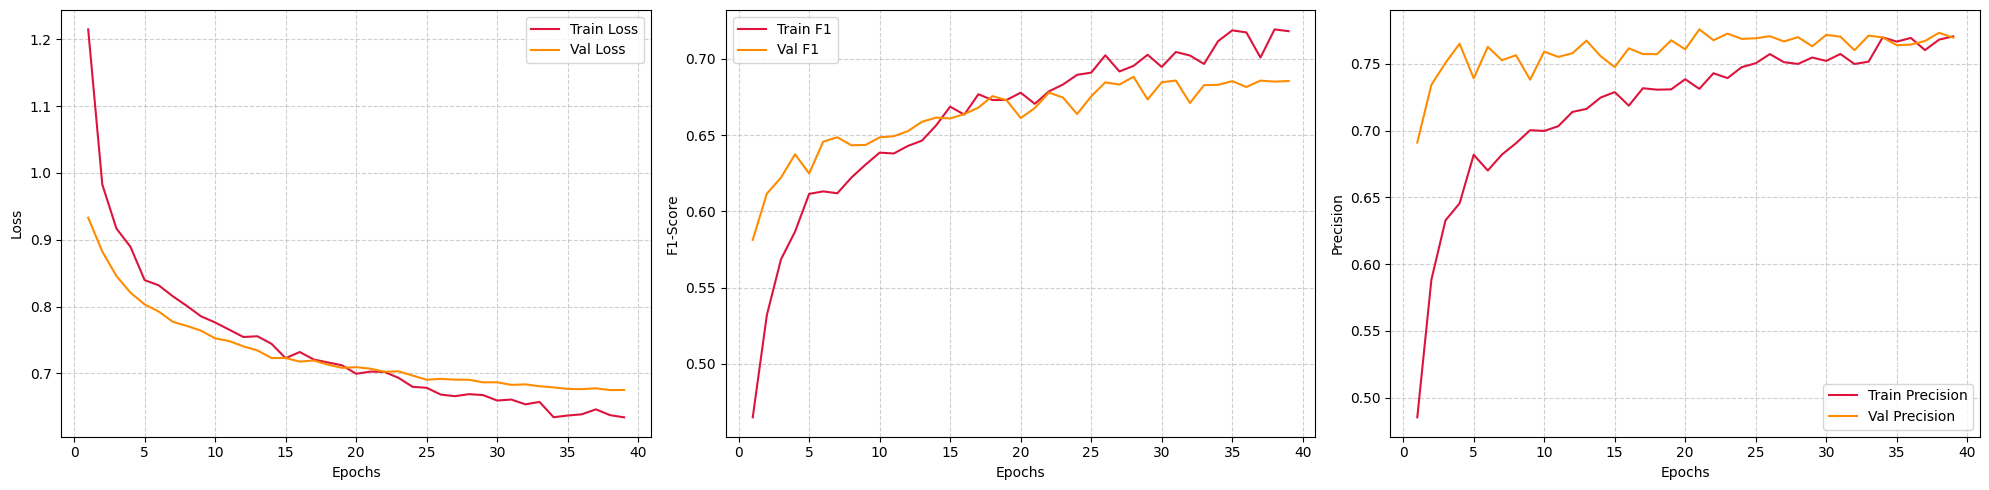

done


In [18]:
# ==========================================================
# PLOT LEARNING CURVES: PHASE 1 (INITIAL, LABELED-ONLY TRAINING)
# ==========================================================
print("start")

if 'history_initial' in globals():
    epochs_range = range(1, len(history_initial.history['loss']) + 1)
    plt.figure(figsize=(20, 5))

    plt.subplot(1, 3, 1)
    plt.plot(epochs_range, history_initial.history['loss'], label='Train Loss', color='crimson')
    plt.plot(epochs_range, history_initial.history['val_loss'], label='Val Loss', color='darkorange')
    plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)

    plt.subplot(1, 3, 2)
    plt.plot(epochs_range, history_initial.history['f1_score'], label='Train F1', color='crimson')
    plt.plot(epochs_range, history_initial.history['val_f1_score'], label='Val F1', color='darkorange')
    plt.xlabel('Epochs'); plt.ylabel('F1-Score'); plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)

    plt.subplot(1, 3, 3)
    plt.plot(epochs_range, history_initial.history['precision'], label='Train Precision', color='crimson')
    plt.plot(epochs_range, history_initial.history['val_precision'], label='Val Precision', color='darkorange')
    plt.xlabel('Epochs'); plt.ylabel('Precision'); plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.savefig("ResNet50_Wavelet_SemiSupervised_Initial_Learning_Curves_v4.pdf", format='pdf', bbox_inches='tight')
    plt.show()
else:
    print("Warning: history_initial not found. Did Phase 1 execute?")

print("done")


start


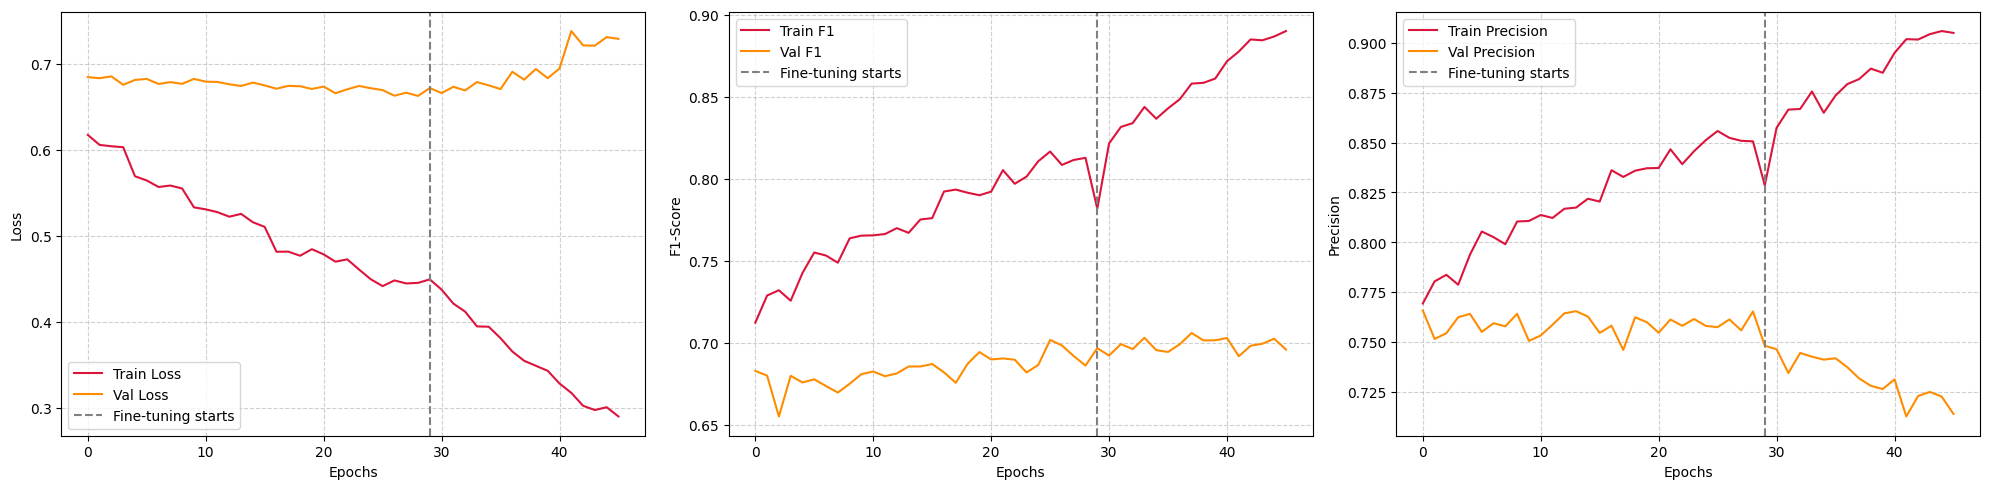

done1


In [19]:
# ==========================================================
# PLOT LEARNING CURVES: PHASE 2 (ITERATIVE SELF-TRAINING) + PHASE 3 (FINE-TUNE)
# ==========================================================
print("start")

def concat_history(h1_dict, h2_keras, key):
    return h1_dict.history[key] + h2_keras.history[key]

if 'history_final' in globals() and 'history_finetune' in globals():
    self_train_end = len(history_final.history['loss'])

    plt.figure(figsize=(20, 5))

    plt.subplot(1, 3, 1)
    plt.plot(concat_history(history_final, history_finetune, 'loss'), label='Train Loss', color='crimson')
    plt.plot(concat_history(history_final, history_finetune, 'val_loss'), label='Val Loss', color='darkorange')
    plt.axvline(self_train_end, linestyle='--', color='gray', label='Fine-tuning starts')
    plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)

    plt.subplot(1, 3, 2)
    plt.plot(concat_history(history_final, history_finetune, 'f1_score'), label='Train F1', color='crimson')
    plt.plot(concat_history(history_final, history_finetune, 'val_f1_score'), label='Val F1', color='darkorange')
    plt.axvline(self_train_end, linestyle='--', color='gray', label='Fine-tuning starts')
    plt.xlabel('Epochs'); plt.ylabel('F1-Score'); plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)

    plt.subplot(1, 3, 3)
    plt.plot(concat_history(history_final, history_finetune, 'precision'), label='Train Precision', color='crimson')
    plt.plot(concat_history(history_final, history_finetune, 'val_precision'), label='Val Precision', color='darkorange')
    plt.axvline(self_train_end, linestyle='--', color='gray', label='Fine-tuning starts')
    plt.xlabel('Epochs'); plt.ylabel('Precision'); plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.savefig("ResNet50_Wavelet_SemiSupervised_Final_Learning_Curves_v4.pdf", format='pdf', bbox_inches='tight')
    plt.show()
else:
    print("Warning: history_final / history_finetune not found.")

print("done1")


In [20]:
# ==========================================================
# FINAL EVALUATION: TRAINING, VALIDATION, AND TEST SETS
# ==========================================================
print("start")

train_eval_generator = ResNetWaveletGenerator(
    train_combined_dir, shuffle=False, labeled=True, augment=False,
    class_indices=train_labeled_generator.class_indices
)

print("\n--- Evaluating Training Dataset (labeled + pseudo-labeled, unaugmented view) ---")
train_results = model.evaluate(train_eval_generator, verbose=1)

print("\n--- Evaluating Validation Dataset ---")
val_results = model.evaluate(val_generator, verbose=1)

print("\n--- Evaluating Test Dataset (unseen) ---")
test_results = model.evaluate(test_generator, verbose=1)

train_loss, train_acc, train_f1, train_precision, train_recall = train_results
val_loss, val_acc, val_f1, val_precision, val_recall = val_results
test_loss, test_acc, test_f1, test_precision, test_recall = test_results

for name, (loss, acc, f1, prec, rec) in [
    ("TRAINING", (train_loss, train_acc, train_f1, train_precision, train_recall)),
    ("VALIDATION", (val_loss, val_acc, val_f1, val_precision, val_recall)),
    ("TESTING (UNSEEN DATA)", (test_loss, test_acc, test_f1, test_precision, test_recall)),
]:
    print("\n" + "=" * 40)
    print(f"{name} METRICS")
    print("=" * 40)
    print(f"Loss      : {loss:.4f}")
    print(f"Accuracy  : {acc*100:.2f}%")
    print(f"F1-Score  : {f1*100:.2f}%")
    print(f"Precision : {prec*100:.2f}%")
    print(f"Recall    : {rec*100:.2f}%")

print("done1")


start

--- Evaluating Training Dataset (labeled + pseudo-labeled, unaugmented view) ---
238/238 [==============================] - 94s 392ms/step - loss: 0.2812 - accuracy: 0.9034 - f1_score: 0.8450 - precision: 0.8678 - recall: 0.8116

--- Evaluating Validation Dataset ---
93/93 [==============================] - 40s 427ms/step - loss: 0.6815 - accuracy: 0.7012 - f1_score: 0.7059 - precision: 0.7317 - recall: 0.6503

--- Evaluating Test Dataset (unseen) ---
92/92 [==============================] - 45s 481ms/step - loss: 0.6944 - accuracy: 0.6976 - f1_score: 0.7009 - precision: 0.7320 - recall: 0.6470

TRAINING METRICS
Loss      : 0.2812
Accuracy  : 90.34%
F1-Score  : 84.50%
Precision : 86.78%
Recall    : 81.16%

VALIDATION METRICS
Loss      : 0.6815
Accuracy  : 70.12%
F1-Score  : 70.59%
Precision : 73.17%
Recall    : 65.03%

TESTING (UNSEEN DATA) METRICS
Loss      : 0.6944
Accuracy  : 69.76%
F1-Score  : 70.09%
Precision : 73.20%
Recall    : 64.70%
done1


In [21]:
# ==========================================================
# INFERENCE & CLASSIFICATION REPORT (Test Set)
# ==========================================================
print("start")

predictions_test = model.predict(test_generator, verbose=1)
predicted_classes_test = np.argmax(predictions_test, axis=1)
true_classes_test = test_generator.labels

print("\nClassification Report:")
print(classification_report(true_classes_test, predicted_classes_test, target_names=class_names))

print("done1")


start
92/92 [==============================] - 37s 394ms/step

Classification Report:
              precision    recall  f1-score   support

      Benign       0.56      0.60      0.58       888
   Malignant       0.73      0.71      0.72      1266
      Normal       0.82      0.79      0.81       789

    accuracy                           0.70      2943
   macro avg       0.70      0.70      0.70      2943
weighted avg       0.70      0.70      0.70      2943

done1


start


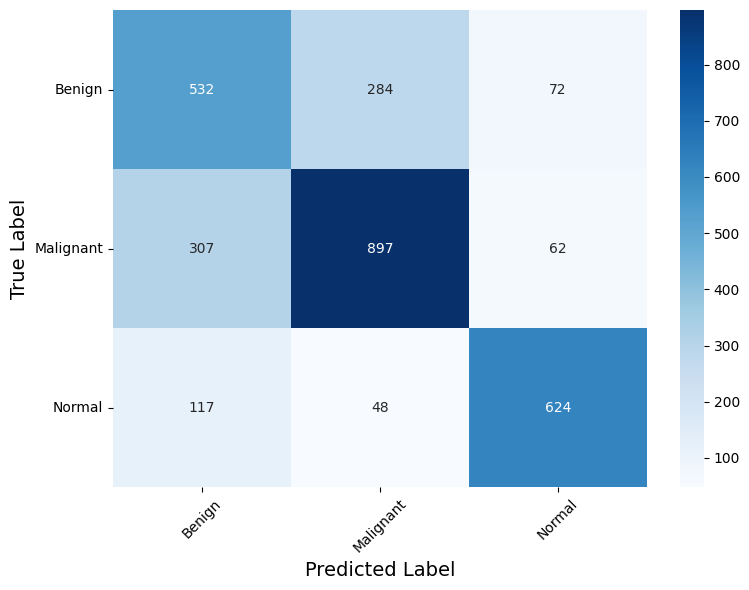


Raw confusion matrix (rows = true label, columns = predicted label):
Classes: ['Benign', 'Malignant', 'Normal']
[[532 284  72]
 [307 897  62]
 [117  48 624]]

Per-class error breakdown (where each class's mistakes actually go):

  True Benign (n=888): 532 correct (59.9%)
    -> misclassified as Malignant: 284 (32.0% of all Benign cases)
    -> misclassified as Normal: 72 (8.1% of all Benign cases)

  True Malignant (n=1266): 897 correct (70.9%)
    -> misclassified as Benign: 307 (24.2% of all Malignant cases)
    -> misclassified as Normal: 62 (4.9% of all Malignant cases)

  True Normal (n=789): 624 correct (79.1%)
    -> misclassified as Benign: 117 (14.8% of all Normal cases)
    -> misclassified as Malignant: 48 (6.1% of all Normal cases)
done1


In [22]:
# ==========================================================
# CONFUSION MATRIX -- PLOT AND RAW NUMBERS  (v4: raw numbers + per-class error breakdown added)
# ==========================================================
# v3 only ever plotted this as a heatmap image, so answering "does Benign get confused with
# Malignant or Normal?" required manually re-deriving the numbers. v4 prints them directly.
print("start")

cm = confusion_matrix(true_classes_test, predicted_classes_test)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.ylabel('True Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)
plt.xticks(rotation=45); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("ResNet50_Wavelet_SemiSupervised_confusion_matrix_test_v4.pdf", format='pdf', bbox_inches='tight')
plt.show()

print("\nRaw confusion matrix (rows = true label, columns = predicted label):")
print("Classes:", class_names)
print(cm)

print("\nPer-class error breakdown (where each class's mistakes actually go):")
for i, true_cls in enumerate(class_names):
    total = cm[i].sum()
    if total == 0:
        continue
    correct = cm[i, i]
    print(f"\n  True {true_cls} (n={total}): {correct} correct ({100*correct/total:.1f}%)")
    for j, pred_cls in enumerate(class_names):
        if i == j:
            continue
        n_err = cm[i, j]
        if n_err > 0:
            print(f"    -> misclassified as {pred_cls}: {n_err} ({100*n_err/total:.1f}% of all {true_cls} cases)")

print("done1")


## Notes & tunable hyperparameters (v4)

- **`CLASS_WEIGHT_MODE = 'recall_inverse'`** (v4 default) -- re-measures which class is weakest every
  run, right before Phase 3, instead of hand-picking one. If it over-corrects (the previously-strong
  classes start regressing), lower `CLASS_WEIGHT_MAX_MULTIPLIER` (e.g. to 2.0) before turning weighting
  off entirely.
- **`USE_GAUSSIAN_NOISE`** (off by default) -- turn on if the train/val F1 gap is still large after the
  `FINETUNE_UNFREEZE_LAST_N` reduction. Raise/lower `GAUSSIAN_NOISE_STD` in small steps (e.g. 2-8) --
  too high will start degrading the fine wavelet-relevant texture detail the same way resampling-based
  augmentation would.
- **`FINETUNE_UNFREEZE_LAST_N` (10)** -- if val F1 still plateaus far below train F1, drop this further
  (e.g. 5) or skip backbone fine-tuning entirely and only fine-tune the fusion head.
- **The per-class error breakdown** printed at the end of Phase 4 is the key diagnostic to watch this
  run: if Benign's misclassifications go mostly to Malignant, that's a genuine clinical-lookalike
  boundary (wavelet texture features may need richer descriptors, or the two classes may need a
  dedicated binary sub-classifier). If they go mostly to Normal, that points somewhere else entirely
  (possibly image quality / contrast issues in the Benign subset specifically).
- **`PER_CLASS_THRESHOLD` / `MAX_ACCEPT_PER_CLASS_PER_ITER`** -- unchanged from v3, already verified
  working (confirmed hitting the cap, not the threshold, for every class every iteration last run).
- Wavelet settings (`WAVELET_NAME`, `WAVELET_LEVEL`) unchanged since v1.
- All checkpoints now save with a `_v4` suffix so they never overwrite your v3 `.h5` files -- you can
  compare both side by side.
